In [1]:
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from collections import defaultdict, Counter

In [2]:
def createDf(data):
    reformed_data = []
    for exp in data:
        base_data = { k:v for k,v in exp.items() if k != "track" }
        for class_name, class_info in exp["track"].items():
            for n_frame, frame_tracks in enumerate(class_info):
                for tracker_id, player_dict in frame_tracks.items():
                    row = base_data.copy()
                    row.update({'class_name': class_name, 'frame': n_frame, 'tracker_id': tracker_id})
                    row.update({
                        "x1": player_dict["bbox"][0],
                        "y1": player_dict["bbox"][1],
                        "w": player_dict["bbox"][2] - player_dict["bbox"][0],
                        "h": player_dict["bbox"][3] - player_dict["bbox"][1],
                        "bbox_size": player_dict["bbox_size"],
                        "confidence": player_dict["confidence"],
                        "Real Madrid": player_dict["distances"]["Real Madrid"],
                        "Wolfsburgo": player_dict["distances"]["Wolfsburgo"],
                        "L": player_dict["shirt_color"][0],
                        "A": player_dict["shirt_color"][1],
                        "B": player_dict["shirt_color"][2],
                        "team": player_dict["team"]
                    } )
                    reformed_data.append(row)
    return pd.DataFrame(reformed_data)

In [3]:
with open("../tracks5.json", "r", encoding="utf-8") as f:
    data5 = json.load(f)
df5 = createDf(data5)
df5

,conf,mcf,mt,tt,class_name,frame,tracker_id,x1,y1,w,h,bbox_size,confidence,Real Madrid,Wolfsburgo,L,A,B,team
0,0.1,4,0.93,0.3,goalkeeper,139,25,169.865128,463.367462,18.848236,54.403168,5832,0.452710,28.086439,28.315059,215.608025,106.388889,141.669753,Real Madrid
1,0.1,4,0.93,0.3,player,2,1,330.658722,492.979706,34.383820,77.110260,8190,0.874298,48.730181,2.334708,229.762755,99.112245,167.112245,Wolfsburgo
2,0.1,4,0.93,0.3,player,2,2,1310.324097,447.935760,43.806152,69.493073,9240,0.856159,54.689381,16.902824,216.592018,90.348115,166.241685,Wolfsburgo
3,0.1,4,0.93,0.3,player,2,3,1230.342896,429.537415,34.873169,72.349731,7560,0.841559,1.457829,47.435027,231.454545,123.977273,124.068182,Real Madrid
4,0.1,4,0.93,0.3,player,2,4,535.753784,687.251404,42.655151,99.685730,12771,0.846290,59.098762,14.947606,224.816049,88.197531,172.067901,Wolfsburgo
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115739,0.1,6,0.96,0.5,referee,198,23,1472.547119,284.473846,16.354492,44.308868,432,0.144300,22.530180,30.680802,217.888889,116.222222,142.000000,Real Madrid
115740,0.1,6,0.96,0.5,referee,198,25,1762.175903,807.629150,25.738037,90.594910,2688,0.620626,160.730545,162.857207,70.550388,119.697674,139.550388,Real Madrid
115741,0.1,6,0.96,0.5,referee,198,26,797.832275,274.968567,13.224609,36.390930,1554,0.748680,173.070269,177.924834,59.414286,143.500000,140.242857,Real Madrid
115742,0.1,6,0.96,0.5,referee,199,25,1760.156616,808.008728,26.785767,90.615967,7020,0.829531,195.357206,198.320469,35.447942,121.680387,134.457627,Real Madrid


In [4]:
def analyze_tracks_no_gt(tracks, class_name="player"):
    frames = tracks[class_name]
    T = len(frames)
    id_frames, id_teams, id_colors, id_bboxes, id_conf, id_bbox_sizes = defaultdict(list), defaultdict(list), defaultdict(list), defaultdict(list), defaultdict(list), defaultdict(list), 
    
    for t, frame_dict in enumerate(frames):
        for tid, info in frame_dict.items():
            id_frames[tid].append(t)
            id_teams[tid].append(info['team']), id_colors[tid].append(info['shirt_color']), id_bboxes[tid].append(info['bbox']), id_conf[tid].append(info['confidence']), id_bbox_sizes[tid].append(info['bbox_size'])
    
    # Metrics per id
    metrics = {}
    num_tracks = 0
    for tid, frames_seen in id_frames.items():
        
        if int(tid) > num_tracks:    num_tracks = int(tid)
        
        frames_seen_sorted = sorted(frames_seen)
        total_seen = len(frames_seen_sorted)
        coverage = total_seen / T

        gap_lengths = []
        movimiento_x = []
        movimiento_y = []
        prev = frames_seen_sorted[0]
        bbox_prev = id_bboxes[tid][0]
        for n_frame, f in enumerate(frames_seen_sorted[1:]):
            frame_gap = f - prev - 1
            if f != prev +1 :
                gap_lengths.append(frame_gap)

            bbox_current = id_bboxes[tid][n_frame]
            x1, y1, _, _ = bbox_current
            x1_prev, y1_prev, _, _ = bbox_prev

            dx, dy = (x1 - x1_prev) / (frame_gap+1), (y1 - y1_prev) / (frame_gap+1)

            movimiento_x.append(dx),  movimiento_y.append(dy)

            prev = f
            bbox_prev = bbox_current

        gaps = len(gap_lengths)
        mean_gap_len = np.mean(gap_lengths) if gap_lengths else 0.0
        mean_speed = np.mean(np.sqrt(np.array(movimiento_x)**2 + np.array(movimiento_y)**2)) if movimiento_x else 0.0
        max_speed = np.max(np.sqrt(np.array(movimiento_x)**2 + np.array(movimiento_y)**2)) if movimiento_x else 0.0
        
        # team stability
        teams = id_teams.get(tid, [])
        team_mode = None
        flip_rate_static, flip_rate_dynamic, entropy = 0.0, 0.0, 0.0
        if teams:
            c = Counter(teams)
            team_mode, _ = c.most_common(1)[0]
            flips_static = sum(1 for x in teams if x != team_mode)
            flips_dynamic = sum(teams[i] != teams[i - 1] for i in range(1, len(teams)))
            flip_rate_static = flips_static / len(teams) if teams else None
            flip_rate_dynamic = flips_dynamic / (len(teams) - 1) if len(teams) > 1 else None

            # entropy
            ps = np.array(list(c.values()))/sum(c.values())
            entropy = -np.sum(ps * np.log2(ps + 1e-12))
        
        # color variance (if numeric)
        colors = np.array(id_colors.get(tid, []), dtype=float) if id_colors.get(tid) else None
        color_var = float(np.mean(np.var(colors, axis=0))) if colors is not None and len(colors)>0 else None
        color_diff = float(np.mean(np.linalg.norm(np.diff(colors, axis=0), axis=1))) if colors is not None and len(colors)>0 else None
        
        # bbox size var
        sizes = np.array(id_bbox_sizes.get(tid, []), dtype=float) if id_bbox_sizes.get(tid) else None
        size_cv = (np.std(sizes)/np.mean(sizes)) if sizes is not None and len(sizes)>1 else None
        
        metrics[tid] = {
            "coverage": coverage, "total_seen": total_seen, "fragments": gaps, "mean_gap_len": mean_gap_len, "mean_speed": mean_speed, "max_speed": max_speed,
            "team_mode": team_mode, "team_flip_rate_static": flip_rate_static, "team_flip_rate_dynamic": flip_rate_dynamic, "team_entropy": entropy,
            "color_var": color_var, "color_diff": color_diff, "bbox_size_cv": size_cv, "mean_confidence": float(np.mean(id_conf[tid])) if id_conf.get(tid) else None
        }
    # Summary stats
    covs = [m["coverage"] for m in metrics.values()]
    total_seen = [m["total_seen"] for m in metrics.values()]
    frag = [m["fragments"] for m in metrics.values()]
    mean_gap_len = [m["mean_gap_len"] for m in metrics.values()]
    mean_speed = [m["mean_speed"] for m in metrics.values()]
    max_speed = [m["max_speed"] for m in metrics.values()]
    flip_rates_static  = [m["team_flip_rate_static" ] for m in metrics.values() if m["team_flip_rate_static"] is not None]
    flip_rates_dynamic = [m["team_flip_rate_dynamic"] for m in metrics.values() if m["team_flip_rate_dynamic"] is not None]
    entropy = [m["team_entropy"] for m in metrics.values()]
    color_var = [m["color_var"] for m in metrics.values()]
    color_diff = [m["color_diff"] for m in metrics.values()]
    bbox_size = [m["bbox_size_cv"] for m in metrics.values() if m["bbox_size_cv"] is not None]
    confidence = [m["mean_confidence"] for m in metrics.values() if m["mean_confidence"] is not None]

    summary = {
        "n_tracks": num_tracks,
        "num_tracks": len(metrics),

        "mean_coverage": float(np.mean(covs)) if covs else 0.0, "median_coverage": float(np.median(covs)) if covs else 0.0, "25_coverage": float(np.quantile(covs, 0.25)) if covs else 0.0,
        "mean_fragments": float(np.mean(frag)) if frag else 0.0, "median_fragments": float(np.median(frag)) if frag else 0.0, "mean_gap_len_mean": float(np.mean(mean_gap_len)) if mean_gap_len else 0.0, "median_gap_len_mean": float(np.median(mean_gap_len)) if mean_gap_len else 0.0, 
        
        "pct_tracks_with_fragments": float(np.mean([1 if f>0 else 0 for f in frag])) if frag else 0.0,

        "mean_speed": float(np.mean(mean_speed) if mean_speed else 0.0),
        "max_speed": float(np.mean(max_speed) if max_speed else 0.0),
        
        "mean_team_flip_rate": float(np.mean(flip_rates_static)) if flip_rates_static else 0.0,
        "mean_team_flip_dynamic": float(np.mean(flip_rates_dynamic)) if flip_rates_dynamic else 0.0,
        "entropy": float(np.mean(entropy)) if entropy else 0.0,
        "color_var": float(np.mean(color_var)) if color_var else 0.0,
        "color_diff": float(np.mean(color_diff)) if color_diff else 0.0,
        "bbox_size": float(np.mean(bbox_size)) if bbox_size else 0.0,
        "confidence": float(np.mean(confidence)) if confidence else 0.0,
    }
    return metrics, summary

In [5]:
rows = []
for exp in data5:
    metrics, summary = analyze_tracks_no_gt(exp["track"])
    row = exp
    row["metrics"] = metrics
    row["summary"] = summary
    rows.append(row)

In [6]:
for i, exp in enumerate(rows):
    exp['experiment_id'] = i
    
df_summary = pd.DataFrame([
    {
        **{k: v for k, v in exp.items() if k not in ['metrics', 'summary', 'track']},
        **exp['summary']
    }
    for exp in rows
])

df_summary

,conf,mcf,mt,tt,experiment_id,n_tracks,num_tracks,mean_coverage,median_coverage,25_coverage,...,pct_tracks_with_fragments,mean_speed,max_speed,mean_team_flip_rate,mean_team_flip_dynamic,entropy,color_var,color_diff,bbox_size,confidence
0,0.1,4,0.930,0.3,0,26,24,0.826667,0.965,0.92375,...,0.541667,3.912899,18.561213,0.028879,0.051706,0.171172,340.174884,13.535297,0.399621,0.764640
1,0.1,5,0.930,0.3,1,27,24,0.821667,0.960,0.91875,...,0.500000,3.635077,17.168187,0.026840,0.043183,0.164499,348.033035,15.082389,0.403552,0.763609
2,0.1,6,0.930,0.3,2,25,23,0.855652,0.965,0.92250,...,0.521739,3.703138,17.692128,0.044562,0.067073,0.244179,471.047063,18.101973,0.413500,0.779569
3,0.1,4,0.945,0.3,3,27,24,0.824375,0.965,0.88250,...,0.541667,3.641563,18.368149,0.032036,0.055982,0.188240,304.835943,12.276175,0.401369,0.780532
4,0.1,5,0.945,0.3,4,27,24,0.819375,0.960,0.87750,...,0.541667,3.668720,18.368149,0.030234,0.045931,0.182351,355.329617,15.003378,0.407325,0.780117
5,0.1,6,0.945,0.3,5,27,24,0.818542,0.960,0.87625,...,0.541667,3.668654,18.368149,0.036185,0.055476,0.207844,375.442516,15.421263,0.403725,0.780180
6,0.1,4,0.960,0.3,6,27,24,0.824375,0.965,0.88250,...,0.541667,3.641563,18.368149,0.032036,0.055982,0.188240,304.835943,12.276175,0.401369,0.780532
7,0.1,5,0.960,0.3,7,27,24,0.819375,0.960,0.87750,...,0.541667,3.668720,18.368149,0.030234,0.045931,0.182351,355.329617,15.003378,0.407325,0.780117
8,0.1,6,0.960,0.3,8,25,23,0.853043,0.965,0.91500,...,0.521739,3.713768,18.767957,0.045577,0.068569,0.249181,463.481760,17.970892,0.412781,0.779860
9,0.1,4,0.930,0.4,9,26,24,0.826250,0.965,0.92500,...,0.500000,3.932894,19.440145,0.034400,0.057185,0.186527,285.673274,11.528442,0.398315,0.764513


In [7]:
rows_detailed = []
for exp in rows:
    exp_info = {k: v for k, v in exp.items() if k not in ['metrics', 'summary', 'track']}
    for tid, m in exp['metrics'].items():
        rows_detailed.append({
            **exp_info,
            "track_id": tid,
            **m
        })

df_tracks = pd.DataFrame(rows_detailed)
df_tracks

,conf,mcf,mt,tt,experiment_id,track_id,coverage,total_seen,fragments,mean_gap_len,mean_speed,max_speed,team_mode,team_flip_rate_static,team_flip_rate_dynamic,team_entropy,color_var,color_diff,bbox_size_cv,mean_confidence
0,0.1,4,0.93,0.3,0,1,0.980,196,0,0.000000,3.202537,10.611729,Wolfsburgo,0.030612,0.061538,0.197453,149.327013,8.341267,0.429832,0.837980
1,0.1,4,0.93,0.3,0,2,0.980,196,1,2.000000,3.247783,15.803012,Wolfsburgo,0.051020,0.061538,0.290716,227.971183,10.256760,0.343509,0.791990
2,0.1,4,0.93,0.3,0,3,0.990,198,0,0.000000,2.946385,9.268063,Real Madrid,0.015152,0.020305,0.113274,235.370053,9.071753,0.365962,0.782511
3,0.1,4,0.93,0.3,0,4,0.990,198,0,0.000000,3.597693,14.408763,Wolfsburgo,0.010101,0.020305,0.081462,27.820274,3.609331,0.448932,0.830645
4,0.1,4,0.93,0.3,0,5,0.990,198,0,0.000000,4.086350,15.645078,Real Madrid,0.010101,0.010152,0.081462,42.467532,3.095984,0.436486,0.857982
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
621,0.1,6,0.96,0.5,26,20,0.905,181,4,4.000000,3.923456,57.815942,Real Madrid,0.027624,0.044444,0.182334,280.400018,10.405961,0.402017,0.802785
622,0.1,6,0.96,0.5,26,21,0.960,192,2,1.500000,6.207419,42.698877,Wolfsburgo,0.052083,0.026178,0.295182,243.028762,9.597722,0.349672,0.804312
623,0.1,6,0.96,0.5,26,22,0.915,183,0,0.000000,3.335126,9.016171,Wolfsburgo,0.081967,0.142857,0.409073,350.204317,16.885624,0.270735,0.803203
624,0.1,6,0.96,0.5,26,23,0.750,150,7,2.428571,4.691969,20.870570,Real Madrid,0.126667,0.167785,0.548225,541.097084,26.938269,0.483564,0.683768


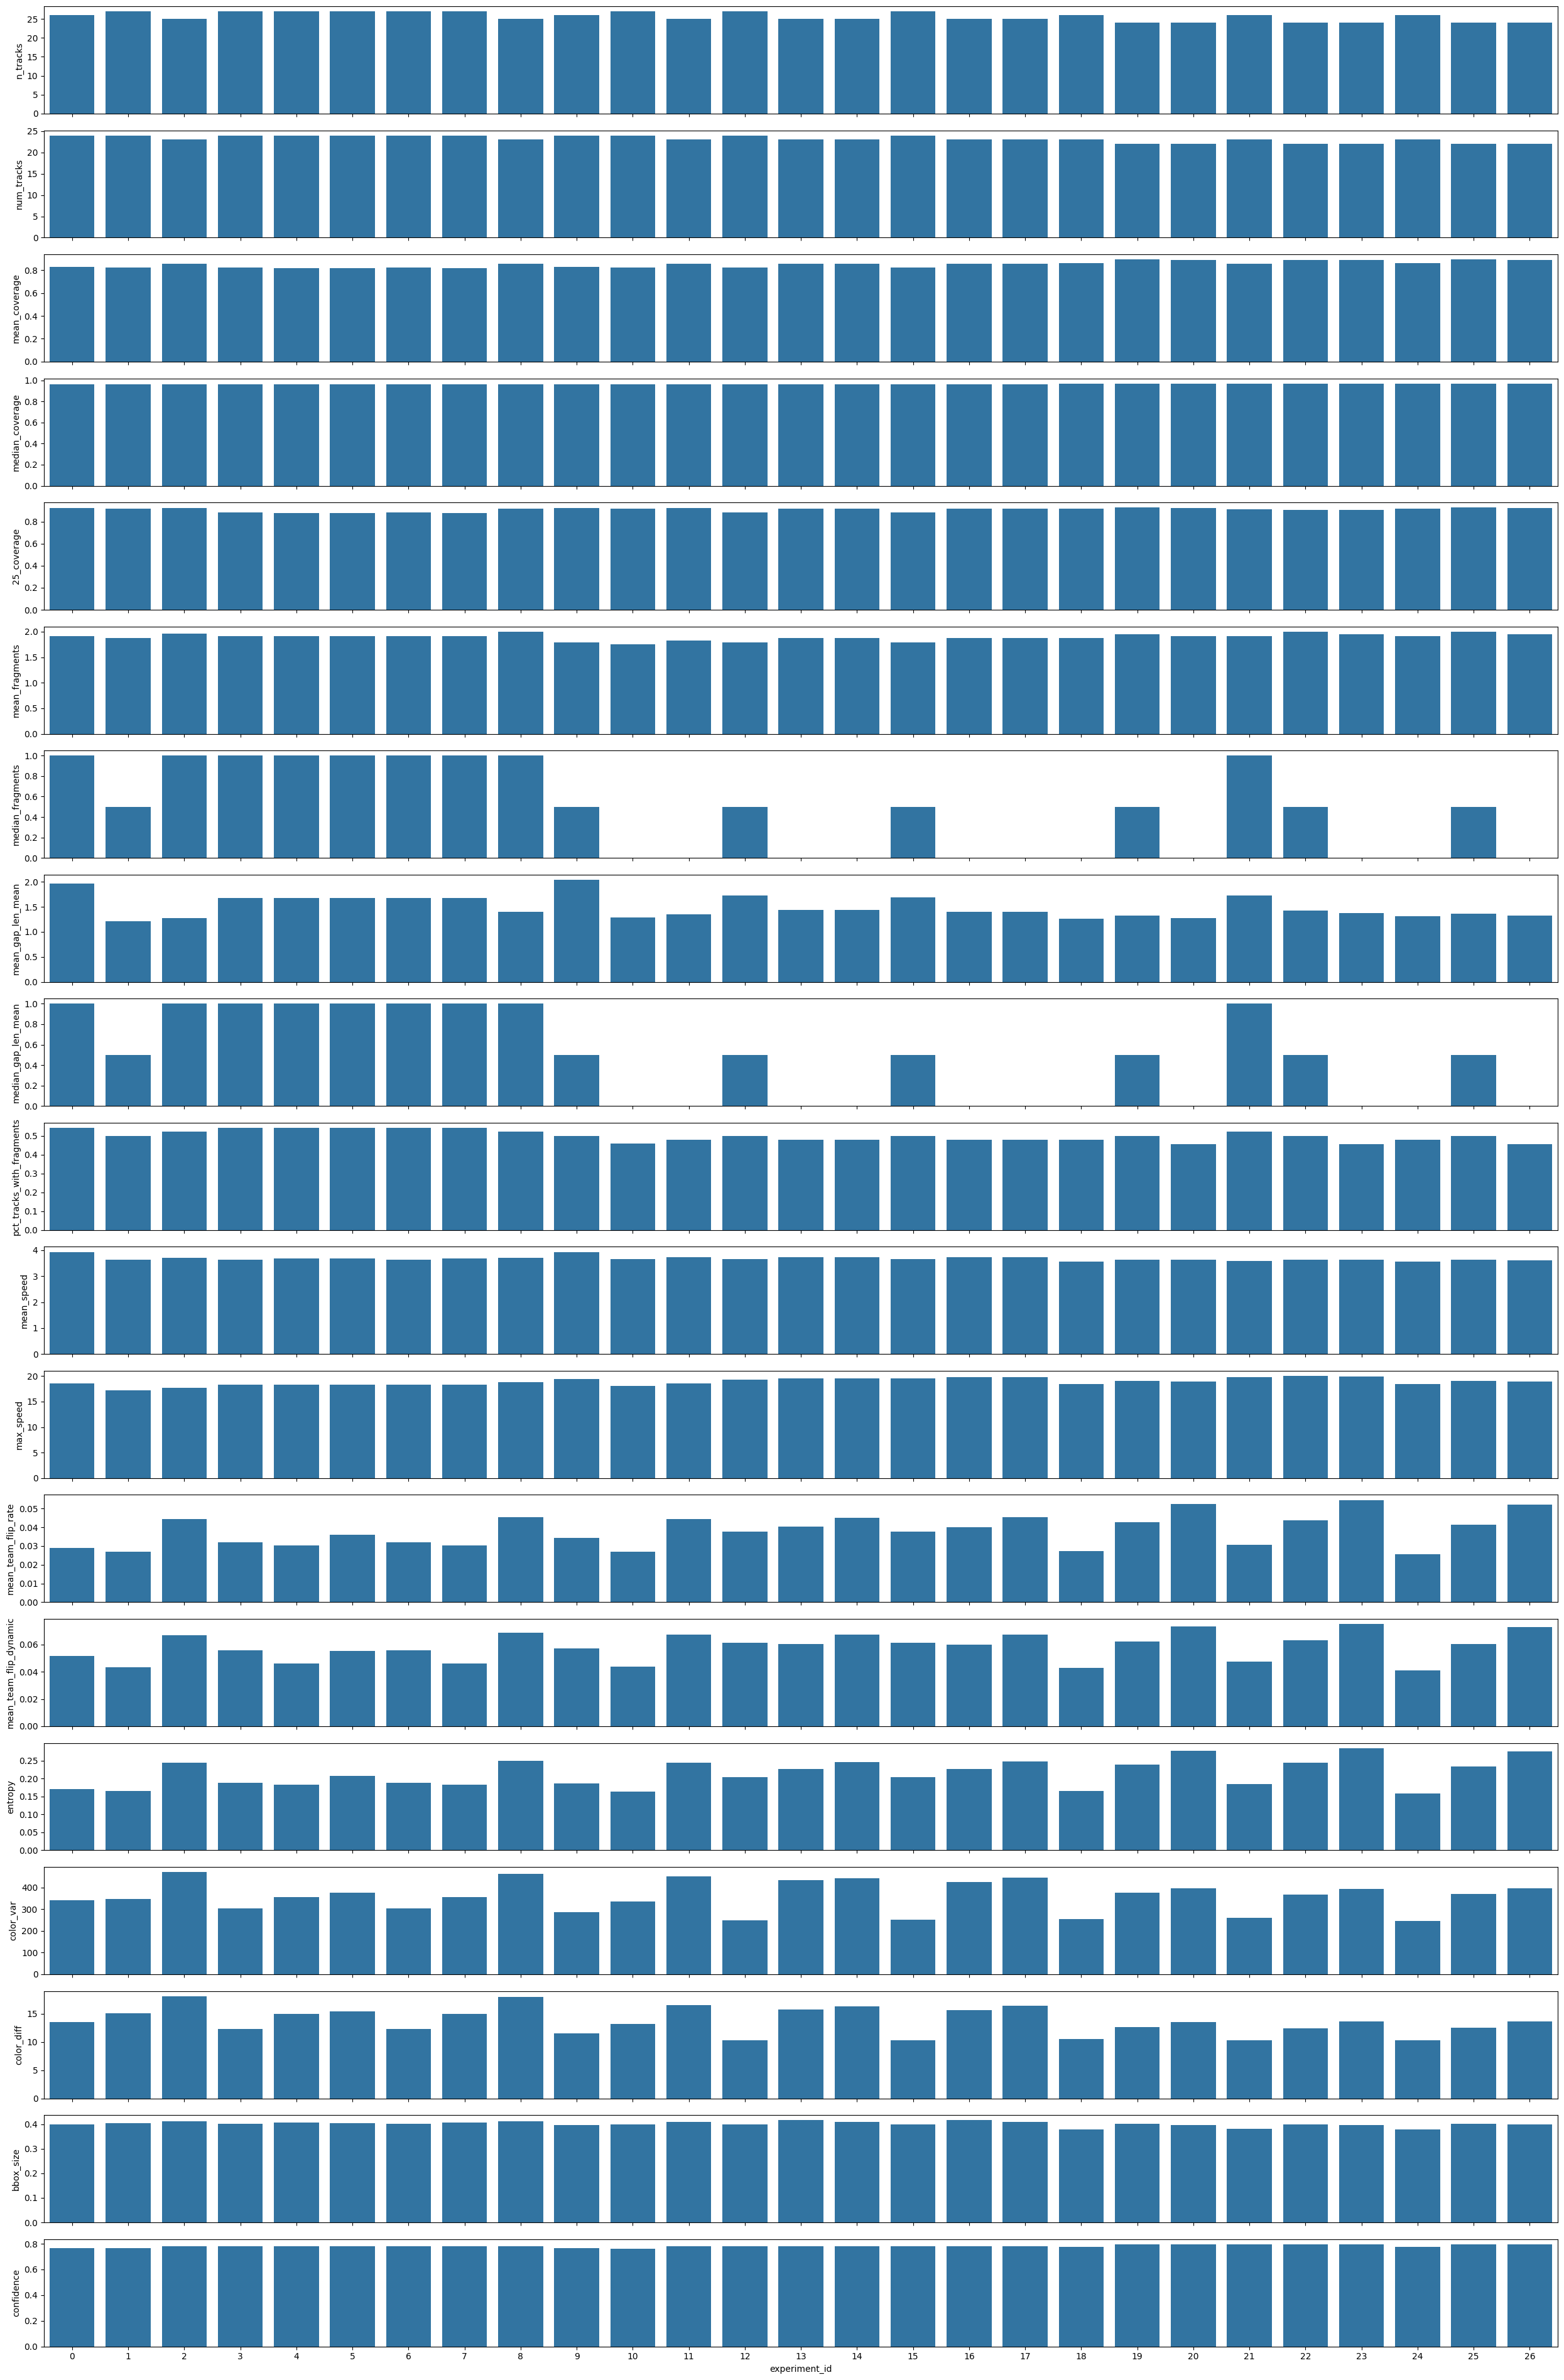

In [8]:
nRows = len(df_summary.columns[5:])
fig, axes = plt.subplots(nRows, 1, figsize=(25,2*nRows), sharex=True)
axes = axes.flatten()
for i, c in enumerate(df_summary.iloc[:, 5:]):
    sns.barplot(data=df_summary, x="experiment_id", y=c, ax=axes[i])
    axes[i].set_ylabel(c)

plt.tight_layout()
plt.show()

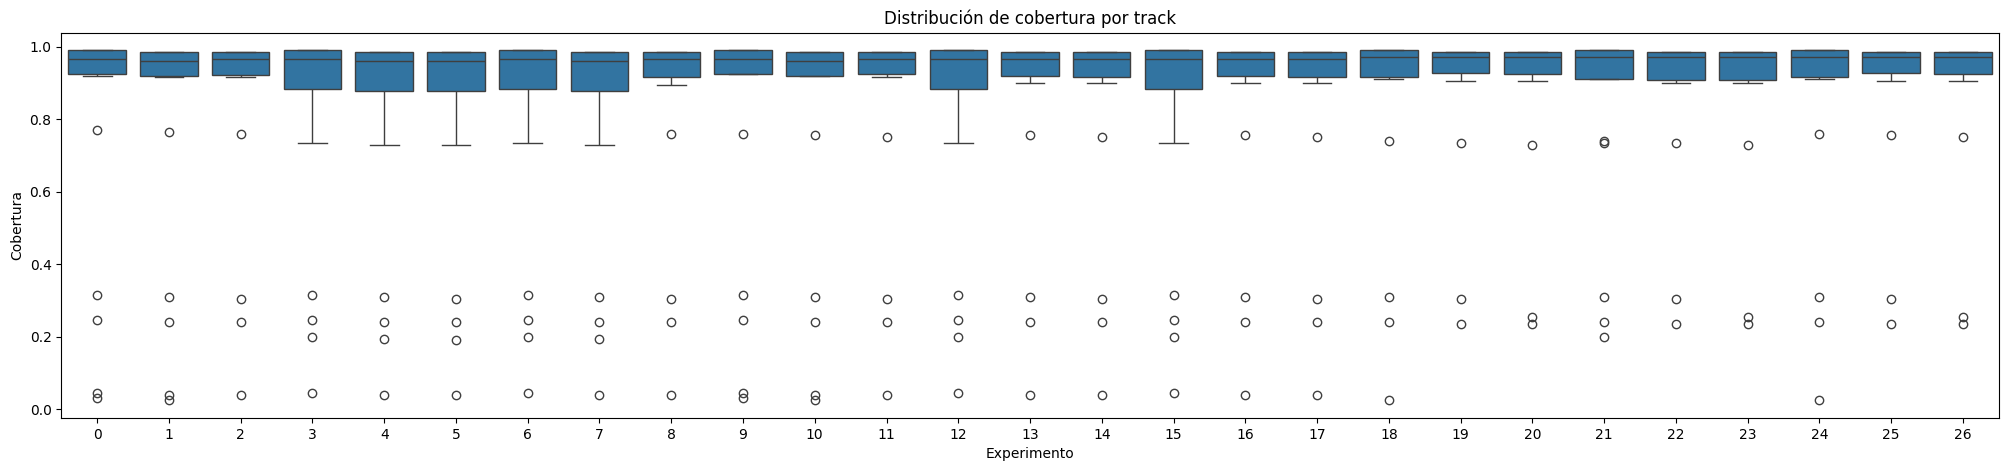

In [9]:
# Distribución de cobertura por track
plt.figure(figsize=(25, 5))
sns.boxplot(data=df_tracks, x="experiment_id", y="coverage")
plt.title("Distribución de cobertura por track")
plt.xlabel("Experimento")
plt.ylabel("Cobertura")
plt.show()

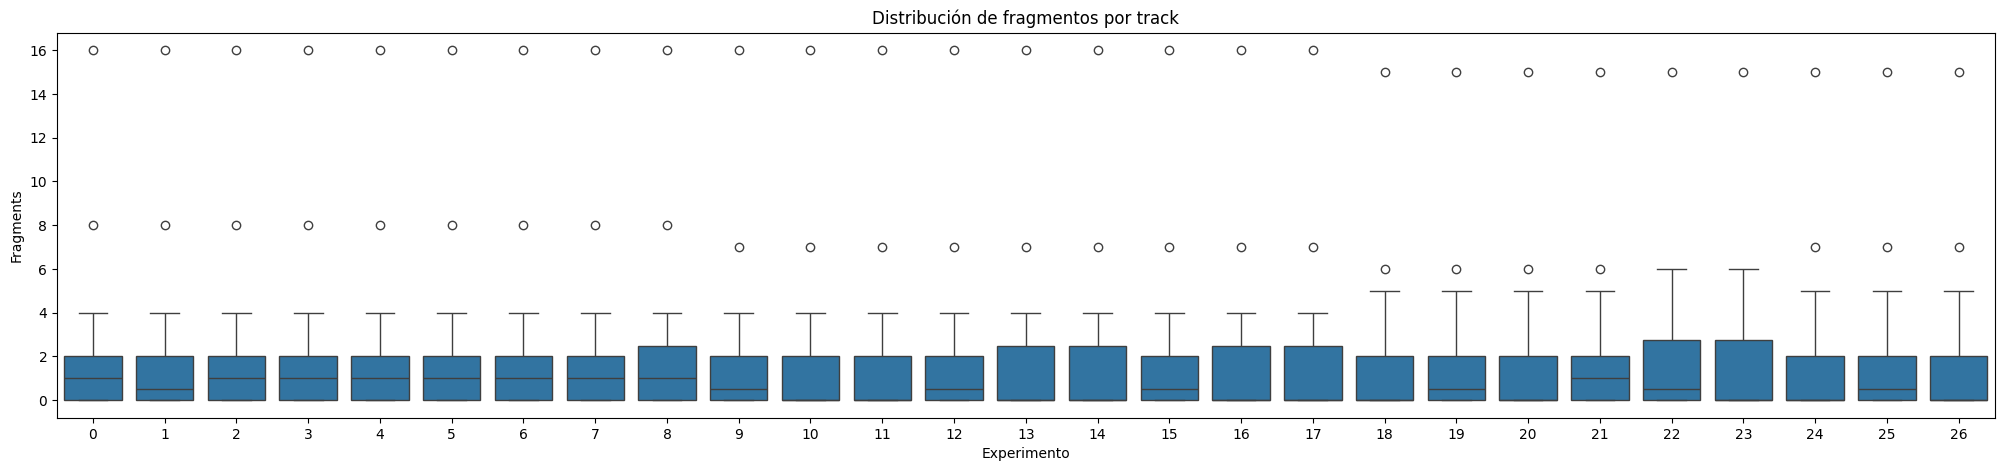

In [10]:
# Distribución de cobertura por track
plt.figure(figsize=(25, 5))
sns.boxplot(data=df_tracks, x="experiment_id", y="fragments")
plt.title("Distribución de fragmentos por track")
plt.xlabel("Experimento")
plt.ylabel("Fragments")
plt.show()

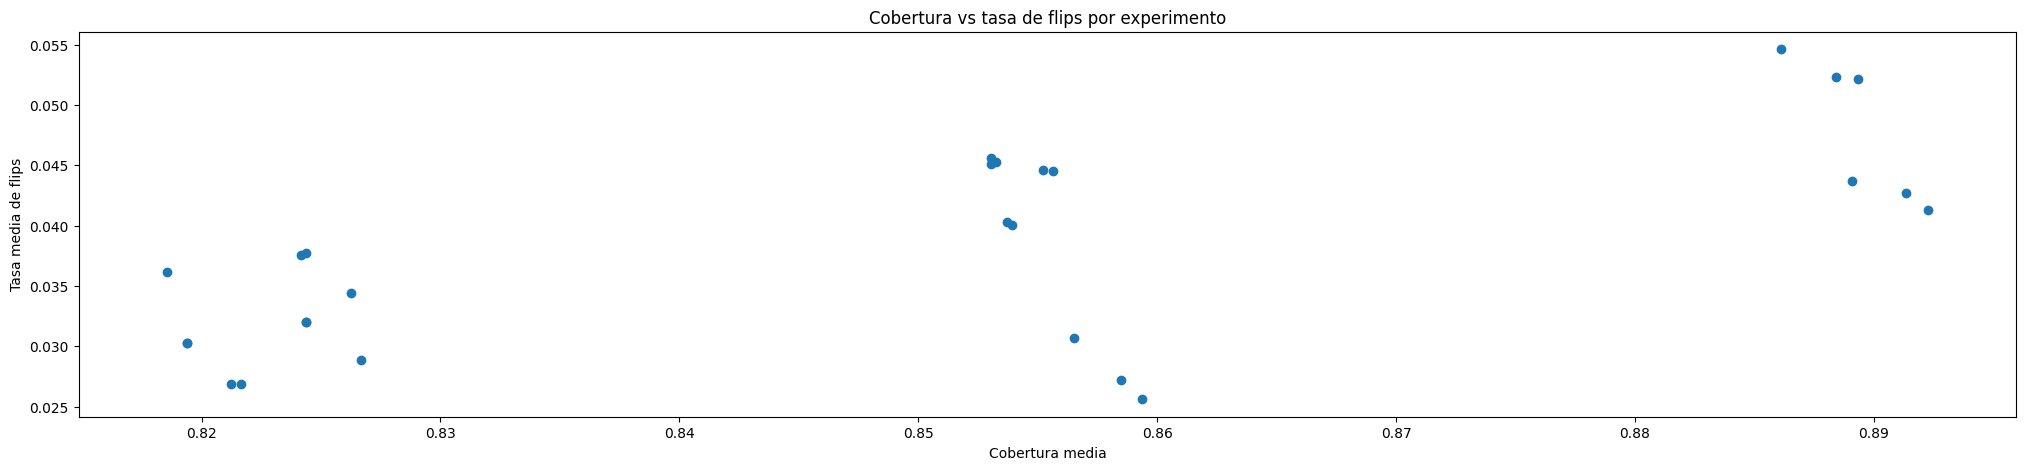

In [11]:
# Scatter: cobertura vs tasa de flips
plt.figure(figsize=(25, 5))
plt.scatter(df_summary["mean_coverage"], df_summary["mean_team_flip_rate"])
plt.xlabel("Cobertura media")
plt.ylabel("Tasa media de flips")
plt.title("Cobertura vs tasa de flips por experimento")
plt.show()

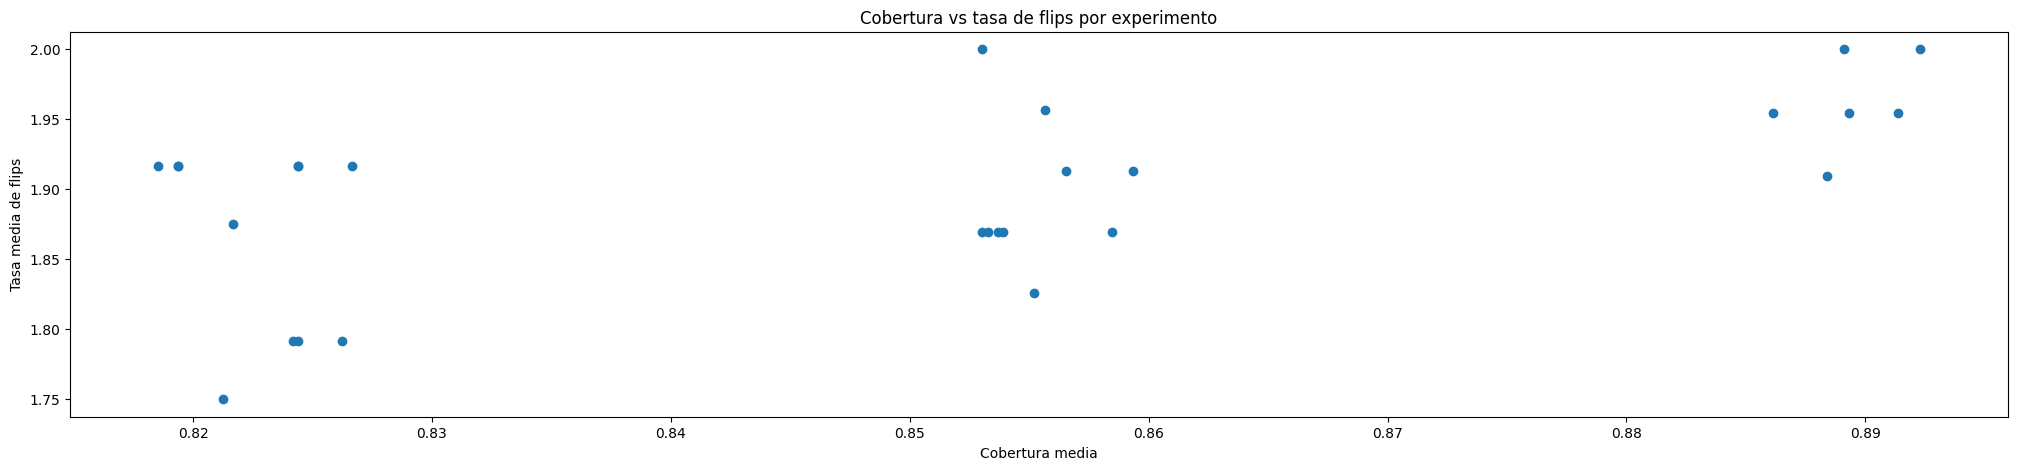

In [12]:
# Scatter: cobertura vs tasa de flips
plt.figure(figsize=(25, 5))
plt.scatter(df_summary["mean_coverage"], df_summary["mean_fragments"])
plt.xlabel("Cobertura media")
plt.ylabel("Tasa media de flips")
plt.title("Cobertura vs tasa de flips por experimento")
plt.show()

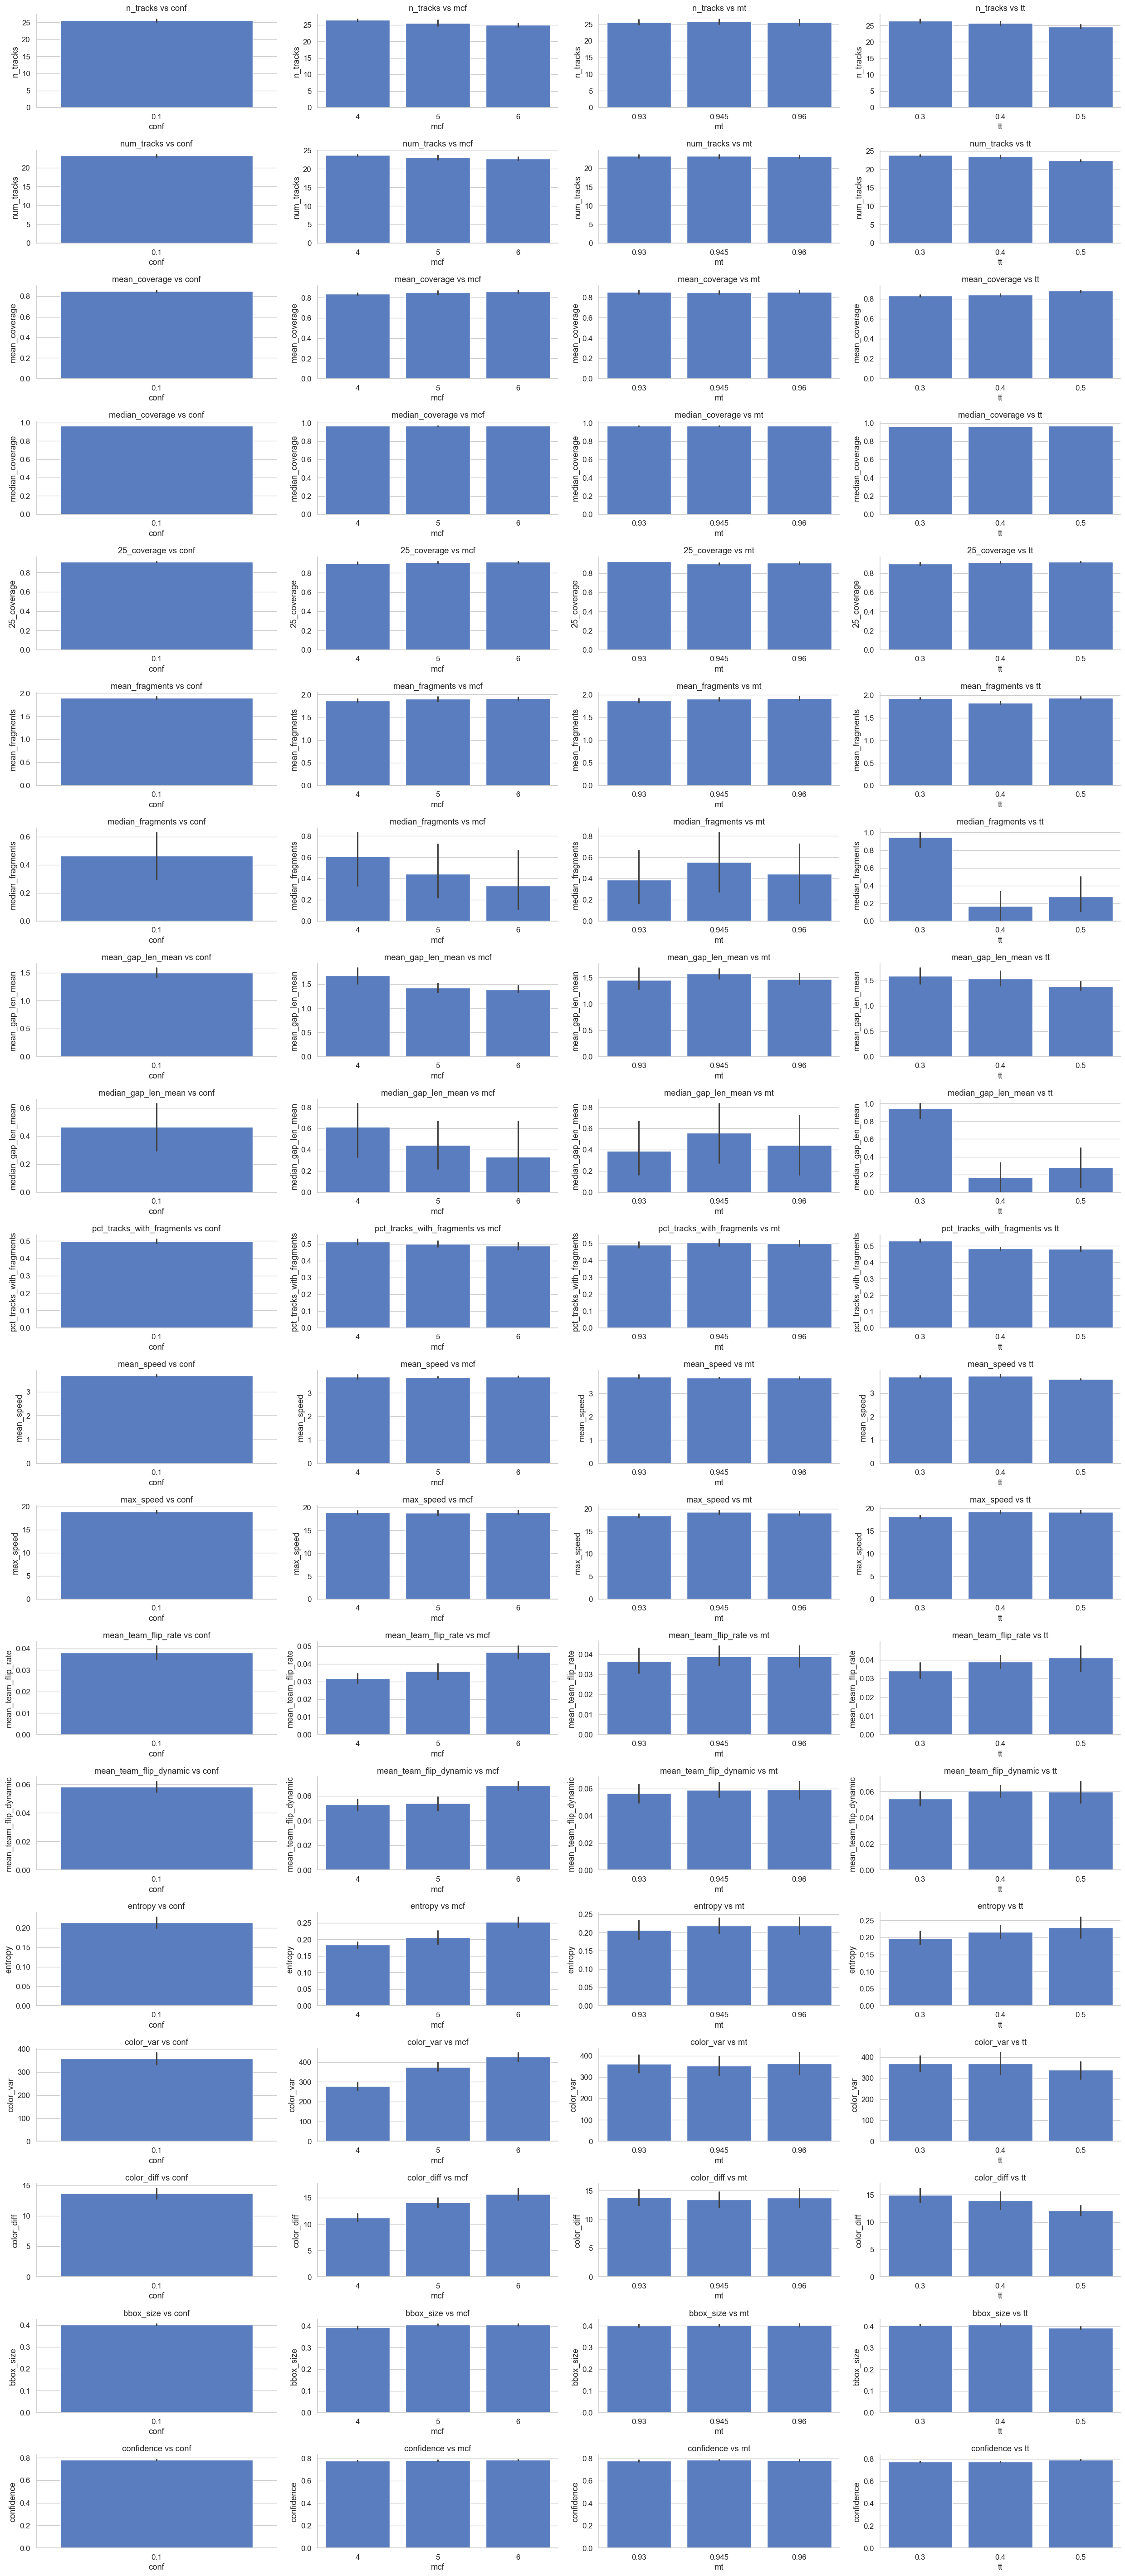

In [13]:
sns.set(style="whitegrid", palette="muted", font_scale=1.1)

params = ['conf', 'mcf', 'mt', 'tt']

nrows = len(df_summary.columns[5:])
ncols = len(params)
fig, axes = plt.subplots(nrows, ncols, figsize=(25, nrows*3))
for i, c in enumerate(df_summary.columns[5:]):
    for j, p in enumerate(params):
        sns.barplot(data=df_summary, x=p, y=c, ax=axes[i, j])
        axes[i, j].set_title(f"{c} vs {p}"), axes[i, j].set_xlabel(p), axes[i, j].set_ylabel(c)

plt.tight_layout()
sns.despine()
plt.show()


In [14]:
df_summary.corr().iloc[5:, 5:]

,n_tracks,num_tracks,mean_coverage,median_coverage,25_coverage,mean_fragments,median_fragments,mean_gap_len_mean,median_gap_len_mean,pct_tracks_with_fragments,mean_speed,max_speed,mean_team_flip_rate,mean_team_flip_dynamic,entropy,color_var,color_diff,bbox_size,confidence
n_tracks,1.000000,0.946079,-0.939577,-0.703472,-0.680259,-0.515202,0.456702,0.496218,0.456702,0.545394,0.030505,-0.500860,-0.800126,-0.707065,-0.823726,-0.575118,-0.242904,-0.131598,-0.643232
num_tracks,0.946079,1.000000,-0.995610,-0.799761,-0.577915,-0.565005,0.468577,0.603351,0.468577,0.570618,0.339826,-0.461693,-0.717436,-0.584633,-0.750813,-0.402891,-0.063877,0.086216,-0.783277
mean_coverage,-0.939577,-0.995610,1.000000,0.841488,0.598582,0.556492,-0.461125,-0.577451,-0.461125,-0.562192,-0.333576,0.456770,0.684347,0.561665,0.714437,0.343191,-0.002381,-0.139197,0.772583
median_coverage,-0.703472,-0.799761,0.841488,1.000000,0.461735,0.410350,-0.349610,-0.272923,-0.349610,-0.430136,-0.334996,0.513925,0.426652,0.379545,0.429868,-0.115116,-0.429458,-0.509736,0.687783
25_coverage,-0.680259,-0.577915,0.598582,0.461735,1.000000,0.070459,-0.543175,-0.479448,-0.543175,-0.600117,0.203585,0.121589,0.301609,0.244842,0.308279,0.372041,0.173513,-0.023288,0.006469
mean_fragments,-0.515202,-0.565005,0.556492,0.410350,0.070459,1.000000,0.340794,-0.227367,0.340794,0.261582,-0.271460,0.024260,0.337434,0.256815,0.399187,0.336877,0.230617,0.015351,0.601905
median_fragments,0.456702,0.468577,-0.461125,-0.349610,-0.543175,0.340794,1.000000,0.568218,1.000000,0.952103,0.134348,-0.349173,-0.350653,-0.261932,-0.334825,-0.169110,0.038984,0.082602,-0.088188
mean_gap_len_mean,0.496218,0.603351,-0.577451,-0.272923,-0.479448,-0.227367,0.568218,1.000000,0.568218,0.615353,0.570433,0.161973,-0.346656,-0.200621,-0.390993,-0.434699,-0.302940,-0.045093,-0.279110
median_gap_len_mean,0.456702,0.468577,-0.461125,-0.349610,-0.543175,0.340794,1.000000,0.568218,1.000000,0.952103,0.134348,-0.349173,-0.350653,-0.261932,-0.334825,-0.169110,0.038984,0.082602,-0.088188
pct_tracks_with_fragments,0.545394,0.570618,-0.562192,-0.430136,-0.600117,0.261582,0.952103,0.615353,0.952103,1.000000,0.190636,-0.349281,-0.469830,-0.369512,-0.448997,-0.189521,0.048729,0.116705,-0.199392


In [29]:
df_summary.sort_values(by="mean_fragments").iloc[:, :15].head()

,conf,mcf,mt,tt,experiment_id,n_tracks,num_tracks,mean_coverage,median_coverage,25_coverage,mean_fragments,median_fragments,mean_gap_len_mean,median_gap_len_mean,pct_tracks_with_fragments
10,0.1,5,0.930,0.4,10,27,24,0.821250,0.960,0.92000,1.750000,0.0,1.292163,0.0,0.458333
12,0.1,4,0.945,0.4,12,27,24,0.824167,0.965,0.88375,1.791667,0.5,1.729663,0.5,0.500000
9,0.1,4,0.930,0.4,9,26,24,0.826250,0.965,0.92500,1.791667,0.5,2.042163,0.5,0.500000
15,0.1,4,0.960,0.4,15,27,24,0.824375,0.965,0.88375,1.791667,0.5,1.687996,0.5,0.500000
11,0.1,6,0.930,0.4,11,25,23,0.855217,0.965,0.92500,1.826087,0.0,1.348344,0.0,0.478261


In [30]:
df_summary.sort_values(by="mean_coverage", ascending=False).iloc[:, :15].head()

,conf,mcf,mt,tt,experiment_id,n_tracks,num_tracks,mean_coverage,median_coverage,25_coverage,mean_fragments,median_fragments,mean_gap_len_mean,median_gap_len_mean,pct_tracks_with_fragments
25,0.1,5,0.960,0.5,25,24,22,0.892273,0.97,0.92750,2.000000,0.5,1.367965,0.5,0.500000
19,0.1,5,0.930,0.5,19,24,22,0.891364,0.97,0.92750,1.954545,0.5,1.325758,0.5,0.500000
26,0.1,6,0.960,0.5,26,24,22,0.889318,0.97,0.92375,1.954545,0.0,1.322511,0.0,0.454545
22,0.1,5,0.945,0.5,22,24,22,0.889091,0.97,0.90875,2.000000,0.5,1.424242,0.5,0.500000
20,0.1,6,0.930,0.5,20,24,22,0.888409,0.97,0.92375,1.909091,0.0,1.280303,0.0,0.454545


In [31]:
df_summary.sort_values(by="median_coverage", ascending=False).iloc[:, :15].head()

,conf,mcf,mt,tt,experiment_id,n_tracks,num_tracks,mean_coverage,median_coverage,25_coverage,mean_fragments,median_fragments,mean_gap_len_mean,median_gap_len_mean,pct_tracks_with_fragments
24,0.1,4,0.96,0.5,24,26,23,0.859348,0.97,0.91750,1.913043,0.0,1.308489,0.0,0.478261
25,0.1,5,0.96,0.5,25,24,22,0.892273,0.97,0.92750,2.000000,0.5,1.367965,0.5,0.500000
26,0.1,6,0.96,0.5,26,24,22,0.889318,0.97,0.92375,1.954545,0.0,1.322511,0.0,0.454545
19,0.1,5,0.93,0.5,19,24,22,0.891364,0.97,0.92750,1.954545,0.5,1.325758,0.5,0.500000
20,0.1,6,0.93,0.5,20,24,22,0.888409,0.97,0.92375,1.909091,0.0,1.280303,0.0,0.454545


In [33]:
df_summary.sort_values(by="mean_speed").iloc[:, :19].head()

,conf,mcf,mt,tt,experiment_id,n_tracks,num_tracks,mean_coverage,median_coverage,25_coverage,mean_fragments,median_fragments,mean_gap_len_mean,median_gap_len_mean,pct_tracks_with_fragments,mean_speed,max_speed,mean_team_flip_rate,mean_team_flip_dynamic
24,0.1,4,0.960,0.5,24,26,23,0.859348,0.97,0.91750,1.913043,0.0,1.308489,0.0,0.478261,3.556532,18.486380,0.025612,0.041159
18,0.1,4,0.930,0.5,18,26,23,0.858478,0.97,0.91750,1.869565,0.0,1.268116,0.0,0.478261,3.557559,18.486380,0.027192,0.043055
21,0.1,4,0.945,0.5,21,26,23,0.856522,0.97,0.91000,1.913043,1.0,1.724638,1.0,0.521739,3.590738,19.738514,0.030658,0.047654
26,0.1,6,0.960,0.5,26,24,22,0.889318,0.97,0.92375,1.954545,0.0,1.322511,0.0,0.454545,3.618843,18.973701,0.052168,0.072882
20,0.1,6,0.930,0.5,20,24,22,0.888409,0.97,0.92375,1.909091,0.0,1.280303,0.0,0.454545,3.619987,18.973701,0.052353,0.073521


In [34]:
df_summary.sort_values(by="max_speed").iloc[:, :19].head()

,conf,mcf,mt,tt,experiment_id,n_tracks,num_tracks,mean_coverage,median_coverage,25_coverage,mean_fragments,median_fragments,mean_gap_len_mean,median_gap_len_mean,pct_tracks_with_fragments,mean_speed,max_speed,mean_team_flip_rate,mean_team_flip_dynamic
1,0.1,5,0.930,0.3,1,27,24,0.821667,0.960,0.91875,1.875000,0.5,1.218750,0.5,0.500000,3.635077,17.168187,0.026840,0.043183
2,0.1,6,0.930,0.3,2,25,23,0.855652,0.965,0.92250,1.956522,1.0,1.271739,1.0,0.521739,3.703138,17.692128,0.044562,0.067073
10,0.1,5,0.930,0.4,10,27,24,0.821250,0.960,0.92000,1.750000,0.0,1.292163,0.0,0.458333,3.655817,18.047119,0.026863,0.043688
3,0.1,4,0.945,0.3,3,27,24,0.824375,0.965,0.88250,1.916667,1.0,1.677083,1.0,0.541667,3.641563,18.368149,0.032036,0.055982
6,0.1,4,0.960,0.3,6,27,24,0.824375,0.965,0.88250,1.916667,1.0,1.677083,1.0,0.541667,3.641563,18.368149,0.032036,0.055982
